# 🤟 ASL Alphabet Recognition — EfficientNetB0 Transfer Learning

**Project:** ASL-Recognition-EfficientNetB0  
**Dataset:** [ASL Alphabet — Kaggle (grassknoted)](https://www.kaggle.com/datasets/grassknoted/asl-alphabet)  
**Classes:** 29 (A–Z + space + delete + nothing)  
**Framework:** TensorFlow / Keras  

---

### Pipeline Overview
1. Mount Google Drive & download dataset via Kaggle API
2. Preprocess images with augmentation
3. Build model on top of EfficientNetB0 (ImageNet weights)
4. Phase 1 — train top layers only
5. Phase 2 — fine-tune last 20 base layers
6. Evaluate: accuracy, confusion matrix, classification report, ROC-AUC
7. Save model to Google Drive

## 1. Environment Setup
Install / verify required libraries. TensorFlow, scikit-learn, and matplotlib are pre-installed on Colab; we only need to confirm GPU availability.

In [2]:
import os, sys, zipfile, shutil, random, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import (
    EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, TensorBoard
)
from tensorflow.keras.utils import plot_model

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize

# ── reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── GPU check ────────────────────────────────────────────────────────────────
gpus = tf.config.list_physical_devices('GPU')
print(f'TensorFlow  : {tf.__version__}')
print(f'GPU devices : {gpus if gpus else "None — training will be slow on CPU"}')

2026-05-15 12:56:14.047358: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778849774.287763      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778849774.355301      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778849774.933807      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778849774.933847      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778849774.933851      57 computation_placer.cc:177] computation placer alr

TensorFlow  : 2.19.0
GPU devices : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Output Paths
All outputs saved to `/kaggle/working/`

In [3]:
WORK_DIR = '/kaggle/working'
TRAIN_DIR = '/kaggle/input/datasets/grassknoted/asl-alphabet/asl_alphabet_train/asl_alphabet_train'
os.makedirs(WORK_DIR, exist_ok=True)
print(f'Working directory: {WORK_DIR}')


Working directory: /kaggle/working


## 3. Kaggle API — Download Dataset

**Before running this cell**, upload your `kaggle.json` API token:
- Go to [kaggle.com → Account → Create New Token](https://www.kaggle.com/settings)
- Upload the downloaded `kaggle.json` using the Colab file browser (left panel → upload icon)
- Then run the cell below

In [4]:
# Dataset already added via Kaggle UI
print(f'Train dir exists: {os.path.isdir(TRAIN_DIR)}')
classes = sorted(os.listdir(TRAIN_DIR))
print(f'Classes found: {len(classes)} → {classes}')


Train dir exists: True
Classes found: 29 → ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## 4. Global Hyperparameters
Centralising all tunable values in one place makes experiments easy to reproduce.

In [5]:
IMG_SIZE      = 224
BATCH_SIZE    = 32
NUM_CLASSES   = 29
VAL_SPLIT     = 0.20

EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 20
LR_PHASE1     = 1e-3
LR_PHASE2     = 1e-4
UNFREEZE_N    = 20

PATIENCE_ES   = 5
PATIENCE_LR   = 3

CKPT_PATH     = '/kaggle/working/best_model.h5'
FINAL_PATH    = '/kaggle/working/asl_efficientnetb0.h5'

print('Hyperparameters loaded ✓')


Hyperparameters loaded ✓


## 5. Data Preprocessing & Augmentation

- **Training** generator: rotation ±15°, zoom ±10%, horizontal flip, brightness shift ±20%  
- **Validation** generator: rescale only (no augmentation — evaluates on clean images)  
- Pixel values normalised to `[0, 1]` via `rescale=1./255`

In [6]:
from tensorflow.keras.applications.efficientnet import preprocess_input

# Training augmentation
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    validation_split       = VAL_SPLIT,
    rotation_range         = 15,
    zoom_range             = 0.10,
    horizontal_flip        = True,
    brightness_range       = [0.80, 1.20],
    width_shift_range      = 0.05,
    height_shift_range     = 0.05,
    fill_mode              = 'nearest',
)

# Validation (no augmentation)
val_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    validation_split       = VAL_SPLIT,
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'training',
    seed         = SEED,
    shuffle      = True,
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    seed         = SEED,
    shuffle      = False,
)

CLASS_NAMES = list(train_gen.class_indices.keys())
print(f'Training   samples : {train_gen.samples}')
print(f'Validation samples : {val_gen.samples}')
print(f'Classes            : {CLASS_NAMES}')


Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.
Training   samples : 69600
Validation samples : 17400
Classes            : ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


### 5.1 Sample Augmented Images
Visualise a batch to confirm augmentation looks reasonable.

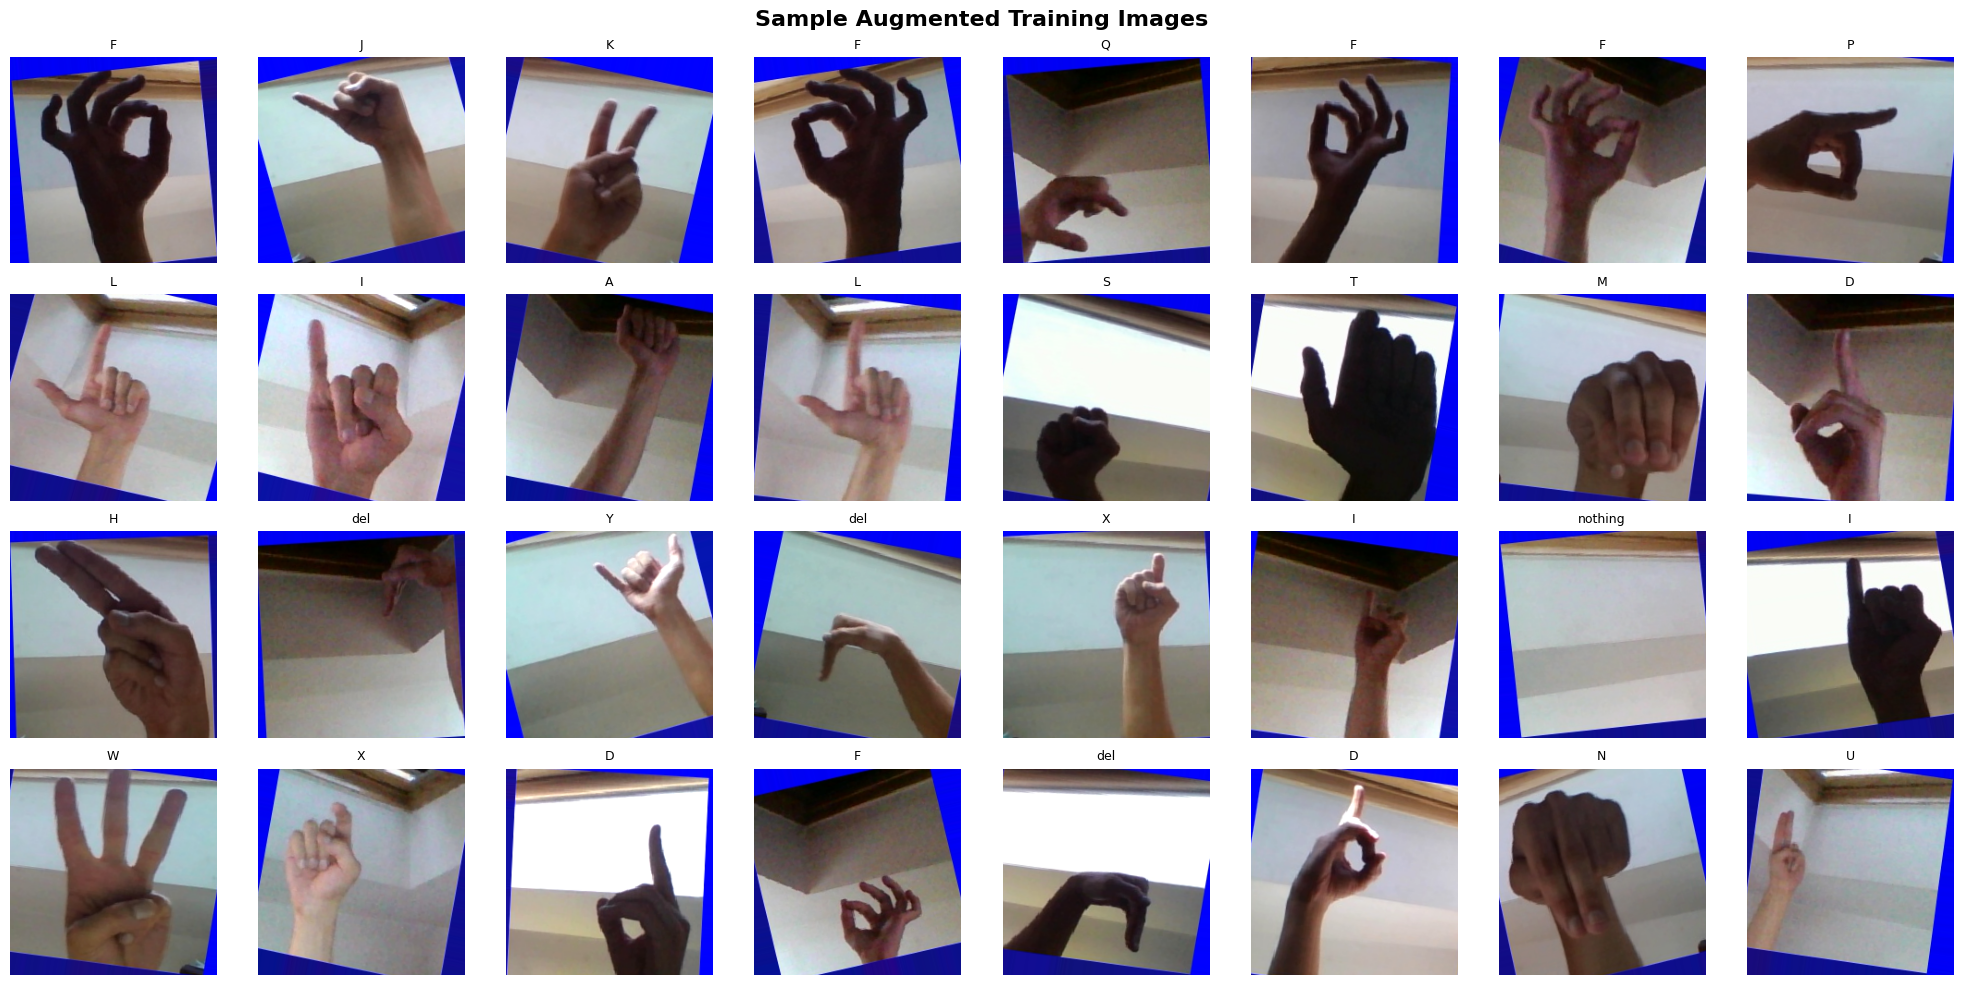

In [7]:
sample_imgs, sample_labels = next(train_gen)

fig, axes = plt.subplots(4, 8, figsize=(20, 10))
fig.suptitle('Sample Augmented Training Images', fontsize=16, fontweight='bold')

for ax, img, lbl in zip(axes.flat, sample_imgs, sample_labels):
    ax.imshow((img - img.min()) / (img.max() - img.min()))  # normalize for display
    ax.set_title(CLASS_NAMES[np.argmax(lbl)], fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'sample_augmented.png'), dpi=120)
plt.show()


## 6. Model Architecture

```
EfficientNetB0 (frozen)  →  GlobalAveragePooling2D
                          →  Dense(256, relu)  +  BatchNorm
                          →  Dropout(0.5)
                          →  Dense(29, softmax)
```

EfficientNetB0 pre-trained on ImageNet provides rich feature representations.  
We freeze the entire base in Phase 1 so only the new head learns.  
In Phase 2 the last 20 layers are unfrozen with a very low learning rate.

In [8]:
def build_model(num_classes: int = NUM_CLASSES,
                img_size: int   = IMG_SIZE,
                freeze_base: bool = True) -> Model:
    """Return compiled EfficientNetB0-based classifier."""
    base = EfficientNetB0(
        include_top  = False,
        weights      = 'imagenet',
        input_shape  = (img_size, img_size, 3),
    )
    base.trainable = not freeze_base

    inputs = keras.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)           # training=False keeps BN frozen
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs, name='ASL_EfficientNetB0')
    return model, base


model, base_model = build_model(freeze_base=True)

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR_PHASE1),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy'],
)

model.summary()
print(f'\nTotal params         : {model.count_params():,}')
print(f'Trainable params     : {sum(tf.size(v).numpy() for v in model.trainable_variables):,}')
print(f'Non-trainable params : {sum(tf.size(v).numpy() for v in model.non_trainable_variables):,}')

I0000 00:00:1778849855.451240      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778849855.457506      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "ASL_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,385,984 (16.73 MB)

 Trainable params: 335,901 (1.28 MB)

 Non-trainable params: 4,050,083 (15.45 MB)


Total params         : 4,385,984
Trainable params     : 335,901
Non-trainable params : 4,050,103


## 7. Callbacks

| Callback | Purpose |
|---|---|
| `ModelCheckpoint` | Save weights whenever `val_accuracy` improves |
| `EarlyStopping` | Stop after `patience=5` epochs without improvement |
| `ReduceLROnPlateau` | Halve LR after `patience=3` stagnant epochs |

In [9]:
def get_callbacks(checkpoint_path: str) -> list:
    return [
        ModelCheckpoint(
            filepath          = checkpoint_path,
            monitor           = 'val_accuracy',
            save_best_only    = True,
            save_weights_only = False,
            verbose           = 1,
        ),
        EarlyStopping(
            monitor              = 'val_accuracy',
            patience             = PATIENCE_ES,
            restore_best_weights = True,
            verbose              = 1,
        ),
        ReduceLROnPlateau(
            monitor  = 'val_loss',
            factor   = 0.5,
            patience = PATIENCE_LR,
            min_lr   = 1e-7,
            verbose  = 1,
        ),
    ]

callbacks = get_callbacks(CKPT_PATH)
print('Callbacks configured ✓')

Callbacks configured ✓


## 8. Phase 1 — Train Top Layers Only
The EfficientNetB0 base is **fully frozen**. Only the custom head (Dense 256 → Dense 29) updates during this phase.  
This quickly aligns the new head with ASL features before we touch the base weights.

In [10]:
print('=' * 60)
print('  PHASE 1 — Top-layer training (base frozen)')
print('=' * 60)

history1 = model.fit(
    train_gen,
    epochs           = EPOCHS_PHASE1,
    validation_data  = val_gen,
    callbacks        = callbacks,
    verbose          = 1,
)

print(f'\nPhase 1 complete. Best val_accuracy: '
      f'{max(history1.history["val_accuracy"]):.4f}')

  PHASE 1 — Top-layer training (base frozen)
Epoch 1/10


I0000 00:00:1778849870.221879     150 service.cc:152] XLA service 0x7fde24114710 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1778849870.221932     150 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1778849870.221939     150 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1778849872.565232     150 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-15 12:58:00.198271: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 12:58:00.341731: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 12:58:00.680788: E external/local_xl

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 617ms/step - accuracy: 0.7975 - loss: 0.7274

2026-05-15 13:23:01.368074: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 13:23:01.510985: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 13:23:01.652673: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 13:23:01.997387: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-15 13:23:02.140435: E external/local_xla/xla/stream_


Epoch 1: val_accuracy improved from -inf to 0.88868, saving model to /kaggle/working/best_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1528s 689ms/step - accuracy: 0.7975 - loss: 0.7272 - val_accuracy: 0.8887 - val_loss: 0.3523 - learning_rate: 0.0010
Epoch 2/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 454ms/step - accuracy: 0.9561 - loss: 0.1415
Epoch 2: val_accuracy improved from 0.88868 to 0.91454, saving model to /kaggle/working/best_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1030s 474ms/step - accuracy: 0.9561 - loss: 0.1415 - val_accuracy: 0.9145 - val_loss: 0.2684 - learning_rate: 0.0010
Epoch 3/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9639 - loss: 0.1109
Epoch 3: val_accuracy improved from 0.91454 to 0.93000, saving model to /kaggle/working/best_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 977s 449ms/step - accuracy: 0.9639 - loss: 0.1109 - val_accuracy: 0.9300 - val_loss: 0.2318 - learning_rate: 0.0010
Epoch 4/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9684 - loss: 0.0974
Epoch 4: val_accuracy did not improve from 0.93000
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 974s 448ms/step - accuracy: 0.9684 - loss: 0.0974 - val_accuracy: 0.9166 - val_loss: 0.2941 - learning_rate: 0.0010
Epoch 5/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9712 - loss: 0.0861
Epoch 5: val_accuracy did not improve from 0.93000
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 999s 459ms/step - accuracy: 0.9712 - loss: 0.0860 - val_accuracy: 0.9248 - val_loss: 0.2439 - learning_rate: 0.0010
Epoch 6/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 460ms/step - accuracy: 0.9721 - loss: 0.0825
Epoch 6: val_accuracy did not improve from 0.93000
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1050s 483ms/step - accuracy: 0.9721 - loss: 0.0825 - val_accuracy: 0.9280 - val_loss: 0.2181 - learning_r

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1017s 467ms/step - accuracy: 0.9767 - loss: 0.0719 - val_accuracy: 0.9310 - val_loss: 0.2471 - learning_rate: 0.0010
Epoch 8/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 445ms/step - accuracy: 0.9781 - loss: 0.0692
Epoch 8: val_accuracy did not improve from 0.93103
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1012s 465ms/step - accuracy: 0.9781 - loss: 0.0692 - val_accuracy: 0.9217 - val_loss: 0.2809 - learning_rate: 0.0010
Epoch 9/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 436ms/step - accuracy: 0.9777 - loss: 0.0676
Epoch 9: val_accuracy did not improve from 0.93103

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 992s 456ms/step - accuracy: 0.9777 - loss: 0.0676 - val_accuracy: 0.9294 - val_loss: 0.2432 - learning_rate: 0.0010
Epoch 10/10
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9837 - loss: 0.0494
Epoch 10: val_accuracy did not improve from 0.93103
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 987s 454ms/step - accura

## 9. Phase 2 — Fine-tune Last 20 Base Layers
Unfreeze the **last 20 layers** of EfficientNetB0 and continue training with a lower learning rate (`1e-4`).  
Fine-tuning upper layers lets the model adapt high-level features to the ASL domain.

In [11]:
# ── unfreeze the top UNFREEZE_N layers of the base model ─────────────────────
base_model.trainable = True

# freeze everything except the last UNFREEZE_N layers
for layer in base_model.layers[:-UNFREEZE_N]:
    layer.trainable = False

# keep BatchNorm layers frozen to preserve ImageNet statistics
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f'Base layers unfrozen : {trainable_count} / {len(base_model.layers)}')

# recompile with lower LR
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR_PHASE2),
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy'],
)

print('=' * 60)
print('  PHASE 2 — Fine-tuning last 20 base layers')
print('=' * 60)

callbacks2 = get_callbacks(CKPT_PATH)   

history2 = model.fit(
    train_gen,
    epochs           = EPOCHS_PHASE2,
    validation_data  = val_gen,
    callbacks        = callbacks2,
    verbose          = 1,
)

print(f'\nPhase 2 complete. Best val_accuracy: '
      f'{max(history2.history["val_accuracy"]):.4f}')

Base layers unfrozen : 15 / 238
  PHASE 2 — Fine-tuning last 20 base layers
Epoch 1/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9912 - loss: 0.0276
Epoch 2: val_accuracy improved from 0.93391 to 0.93983, saving model to /kaggle/working/best_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1028s 473ms/step - accuracy: 0.9912 - loss: 0.0276 - val_accuracy: 0.9398 - val_loss: 0.2273 - learning_rate: 1.0000e-04
Epoch 3/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9949 - loss: 0.0155
Epoch 3: val_accuracy improved from 0.93983 to 0.95063, saving model to /kaggle/working/best_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1015s 467ms/step - accuracy: 0.9949 - loss: 0.0155 - val_accuracy: 0.9506 - val_loss: 0.1781 - learning_rate: 1.0000e-04
Epoch 4/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 458ms/step - accuracy: 0.9955 - loss: 0.0135
Epoch 4: val_accuracy improved from 0.95063 to 0.95782, saving model to /kaggle/working/best_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1045s 480ms/step - accuracy: 0.9955 - loss: 0.0135 - val_accuracy: 0.9578 - val_loss: 0.1680 - learning_rate: 1.0000e-04
Epoch 5/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.9964 - loss: 0.0103
Epoch 5: val_accuracy did not improve from 0.95782
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1001s 460ms/step - accuracy: 0.9964 - loss: 0.0103 - val_accuracy: 0.9512 - val_loss: 0.1870 - learning_rate: 1.0000e-04
Epoch 6/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 433ms/step - accuracy: 0.9973 - loss: 0.0085
Epoch 6: val_accuracy did not improve from 0.95782
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 980s 451ms/step - accuracy: 0.9973 - loss: 0.0085 - val_accuracy: 0.9575 - val_loss: 0.1549 - learning_rate: 1.0000e-04
Epoch 7/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.9972 - loss: 0.0090
Epoch 7: val_accuracy did not improve from 0.95782
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 981s 451ms/step - accuracy: 0.9972 - loss: 0.0090 - val_accuracy: 0.9493 - val_loss: 0.2106

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1005s 462ms/step - accuracy: 0.9980 - loss: 0.0072 - val_accuracy: 0.9611 - val_loss: 0.1344 - learning_rate: 1.0000e-04
Epoch 10/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 453ms/step - accuracy: 0.9986 - loss: 0.0039
Epoch 10: val_accuracy did not improve from 0.96109
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1031s 474ms/step - accuracy: 0.9986 - loss: 0.0039 - val_accuracy: 0.9479 - val_loss: 0.2568 - learning_rate: 1.0000e-04
Epoch 11/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.9981 - loss: 0.0053
Epoch 11: val_accuracy did not improve from 0.96109
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1023s 470ms/step - accuracy: 0.9981 - loss: 0.0053 - val_accuracy: 0.9576 - val_loss: 0.1923 - learning_rate: 1.0000e-04
Epoch 12/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9979 - loss: 0.0055
Epoch 12: val_accuracy did not improve from 0.96109

Epoch 12: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1011s 

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1000s 460ms/step - accuracy: 0.9992 - loss: 0.0022 - val_accuracy: 0.9633 - val_loss: 0.1769 - learning_rate: 5.0000e-05
Epoch 14/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.9991 - loss: 0.0029
Epoch 14: val_accuracy did not improve from 0.96328
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1027s 472ms/step - accuracy: 0.9991 - loss: 0.0029 - val_accuracy: 0.9622 - val_loss: 0.2024 - learning_rate: 5.0000e-05
Epoch 15/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.9996 - loss: 0.0013
Epoch 15: val_accuracy did not improve from 0.96328

Epoch 15: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1010s 464ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.9625 - val_loss: 0.1788 - learning_rate: 5.0000e-05
Epoch 16/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.9995 - loss: 0.0018
Epoch 16: val_accuracy improved from 0.96328 to 0.96460, saving model to /kaggle/working/

2175/2175 ━━━━━━━━━━━━━━━━━━━━ 996s 458ms/step - accuracy: 0.9995 - loss: 0.0018 - val_accuracy: 0.9646 - val_loss: 0.1704 - learning_rate: 2.5000e-05
Epoch 17/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step - accuracy: 0.9996 - loss: 0.0013
Epoch 17: val_accuracy did not improve from 0.96460
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1006s 463ms/step - accuracy: 0.9996 - loss: 0.0013 - val_accuracy: 0.9622 - val_loss: 0.1689 - learning_rate: 2.5000e-05
Epoch 18/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9997 - loss: 8.9007e-04
Epoch 18: val_accuracy improved from 0.96460 to 0.96540, saving model to /kaggle/working/best_model.h5



Epoch 18: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-05.
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1008s 463ms/step - accuracy: 0.9997 - loss: 8.9013e-04 - val_accuracy: 0.9654 - val_loss: 0.1569 - learning_rate: 2.5000e-05
Epoch 19/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 443ms/step - accuracy: 0.9998 - loss: 7.0640e-04
Epoch 19: val_accuracy improved from 0.96540 to 0.96764, saving model to /kaggle/working/best_model.h5


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1006s 463ms/step - accuracy: 0.9998 - loss: 7.0644e-04 - val_accuracy: 0.9676 - val_loss: 0.1342 - learning_rate: 1.2500e-05
Epoch 20/20
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9997 - loss: 9.3227e-04
Epoch 20: val_accuracy did not improve from 0.96764
2175/2175 ━━━━━━━━━━━━━━━━━━━━ 1003s 461ms/step - accuracy: 0.9997 - loss: 9.3232e-04 - val_accuracy: 0.9671 - val_loss: 0.1365 - learning_rate: 1.2500e-05
Restoring model weights from the end of the best epoch: 19.

Phase 2 complete. Best val_accuracy: 0.9676


## 10. Training Curves
Concatenate both phases so we can see the full training trajectory.

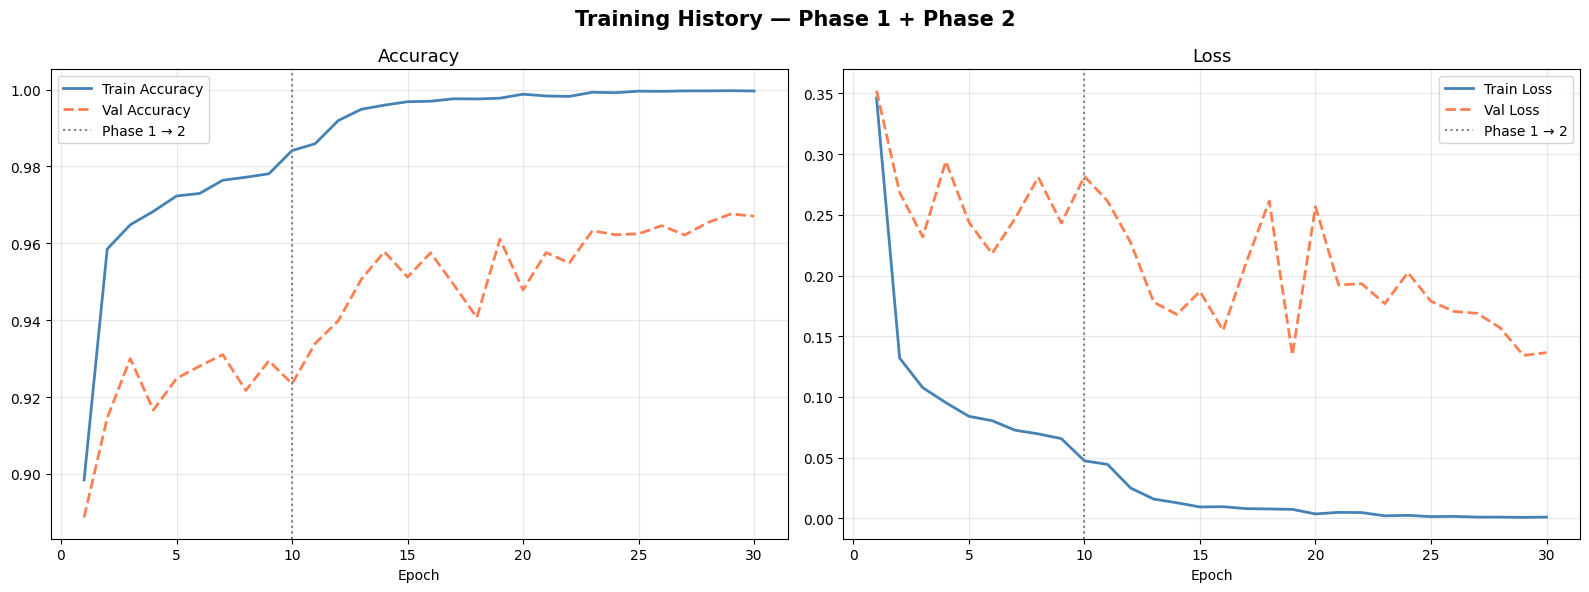

In [12]:
def merge_histories(h1, h2):
    """Concatenate two Keras History objects into one dict."""
    merged = {}
    for key in h1.history:
        merged[key] = h1.history[key] + h2.history.get(key, [])
    return merged

history = merge_histories(history1, history2)
phase1_end = len(history1.history['loss'])

epochs_range = range(1, len(history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Training History — Phase 1 + Phase 2', fontsize=15, fontweight='bold')

for ax, metric, title in zip(
        axes,
        [('accuracy', 'val_accuracy'), ('loss', 'val_loss')],
        ['Accuracy', 'Loss']):

    train_key, val_key = metric
    ax.plot(epochs_range, history[train_key], label=f'Train {title}',
            color='steelblue', linewidth=2)
    ax.plot(epochs_range, history[val_key],   label=f'Val {title}',
            color='coral',    linewidth=2, linestyle='--')
    ax.axvline(phase1_end, color='grey', linestyle=':', linewidth=1.5,
               label='Phase 1 → 2')
    ax.set_title(title, fontsize=13)
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'training_curves.png'), dpi=150)
plt.show()

## 11. Load Best Model & Predict on Validation Set
Load the checkpoint saved by `ModelCheckpoint` — this is the epoch with the highest validation accuracy.

In [13]:
from tensorflow.keras.applications.efficientnet import preprocess_input

print(f'Loading best checkpoint from {CKPT_PATH}')
best_model = keras.models.load_model(CKPT_PATH)

eval_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    validation_split       = VAL_SPLIT,
)
eval_gen = eval_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = (IMG_SIZE, IMG_SIZE),
    batch_size   = BATCH_SIZE,
    class_mode   = 'categorical',
    subset       = 'validation',
    seed         = SEED,
    shuffle      = False,
)

loss, accuracy = best_model.evaluate(eval_gen, verbose=1)
print(f'\nValidation Loss     : {loss:.4f}')
print(f'Validation Accuracy : {accuracy * 100:.2f} %')

eval_gen.reset()
y_pred_proba = best_model.predict(eval_gen, verbose=1)
y_pred       = np.argmax(y_pred_proba, axis=1)
y_true       = eval_gen.classes


Loading best checkpoint from /kaggle/working/best_model.h5


Found 17400 images belonging to 29 classes.
544/544 ━━━━━━━━━━━━━━━━━━━━ 44s 66ms/step - accuracy: 0.9787 - loss: 0.0842

Validation Loss     : 0.1504
Validation Accuracy : 96.29 %
544/544 ━━━━━━━━━━━━━━━━━━━━ 46s 72ms/step


## 12. Evaluation

### 12.1 Classification Report

In [14]:
report = classification_report(
    y_true, y_pred,
    target_names = CLASS_NAMES,
    digits       = 4,
)
print('Classification Report')
print('=' * 80)
print(report)

with open(os.path.join(WORK_DIR, 'classification_report.txt'), 'w') as f:
    f.write(report)


Classification Report
              precision    recall  f1-score   support

           A     0.9901    1.0000    0.9950       600
           B     0.9934    1.0000    0.9967       600
           C     0.9983    1.0000    0.9992       600
           D     0.9967    0.9983    0.9975       600
           E     0.9569    1.0000    0.9780       600
           F     1.0000    1.0000    1.0000       600
           G     0.9620    0.9700    0.9660       600
           H     0.9539    1.0000    0.9764       600
           I     0.9750    0.9083    0.9405       600
           J     0.9590    0.8967    0.9268       600
           K     0.9983    0.9933    0.9958       600
           L     1.0000    1.0000    1.0000       600
           M     0.9704    0.9283    0.9489       600
           N     0.8998    0.9733    0.9351       600
           O     1.0000    0.9850    0.9924       600
           P     0.9380    0.9833    0.9601       600
           Q     0.9982    0.9350    0.9656       600
     

### 12.2 Confusion Matrix

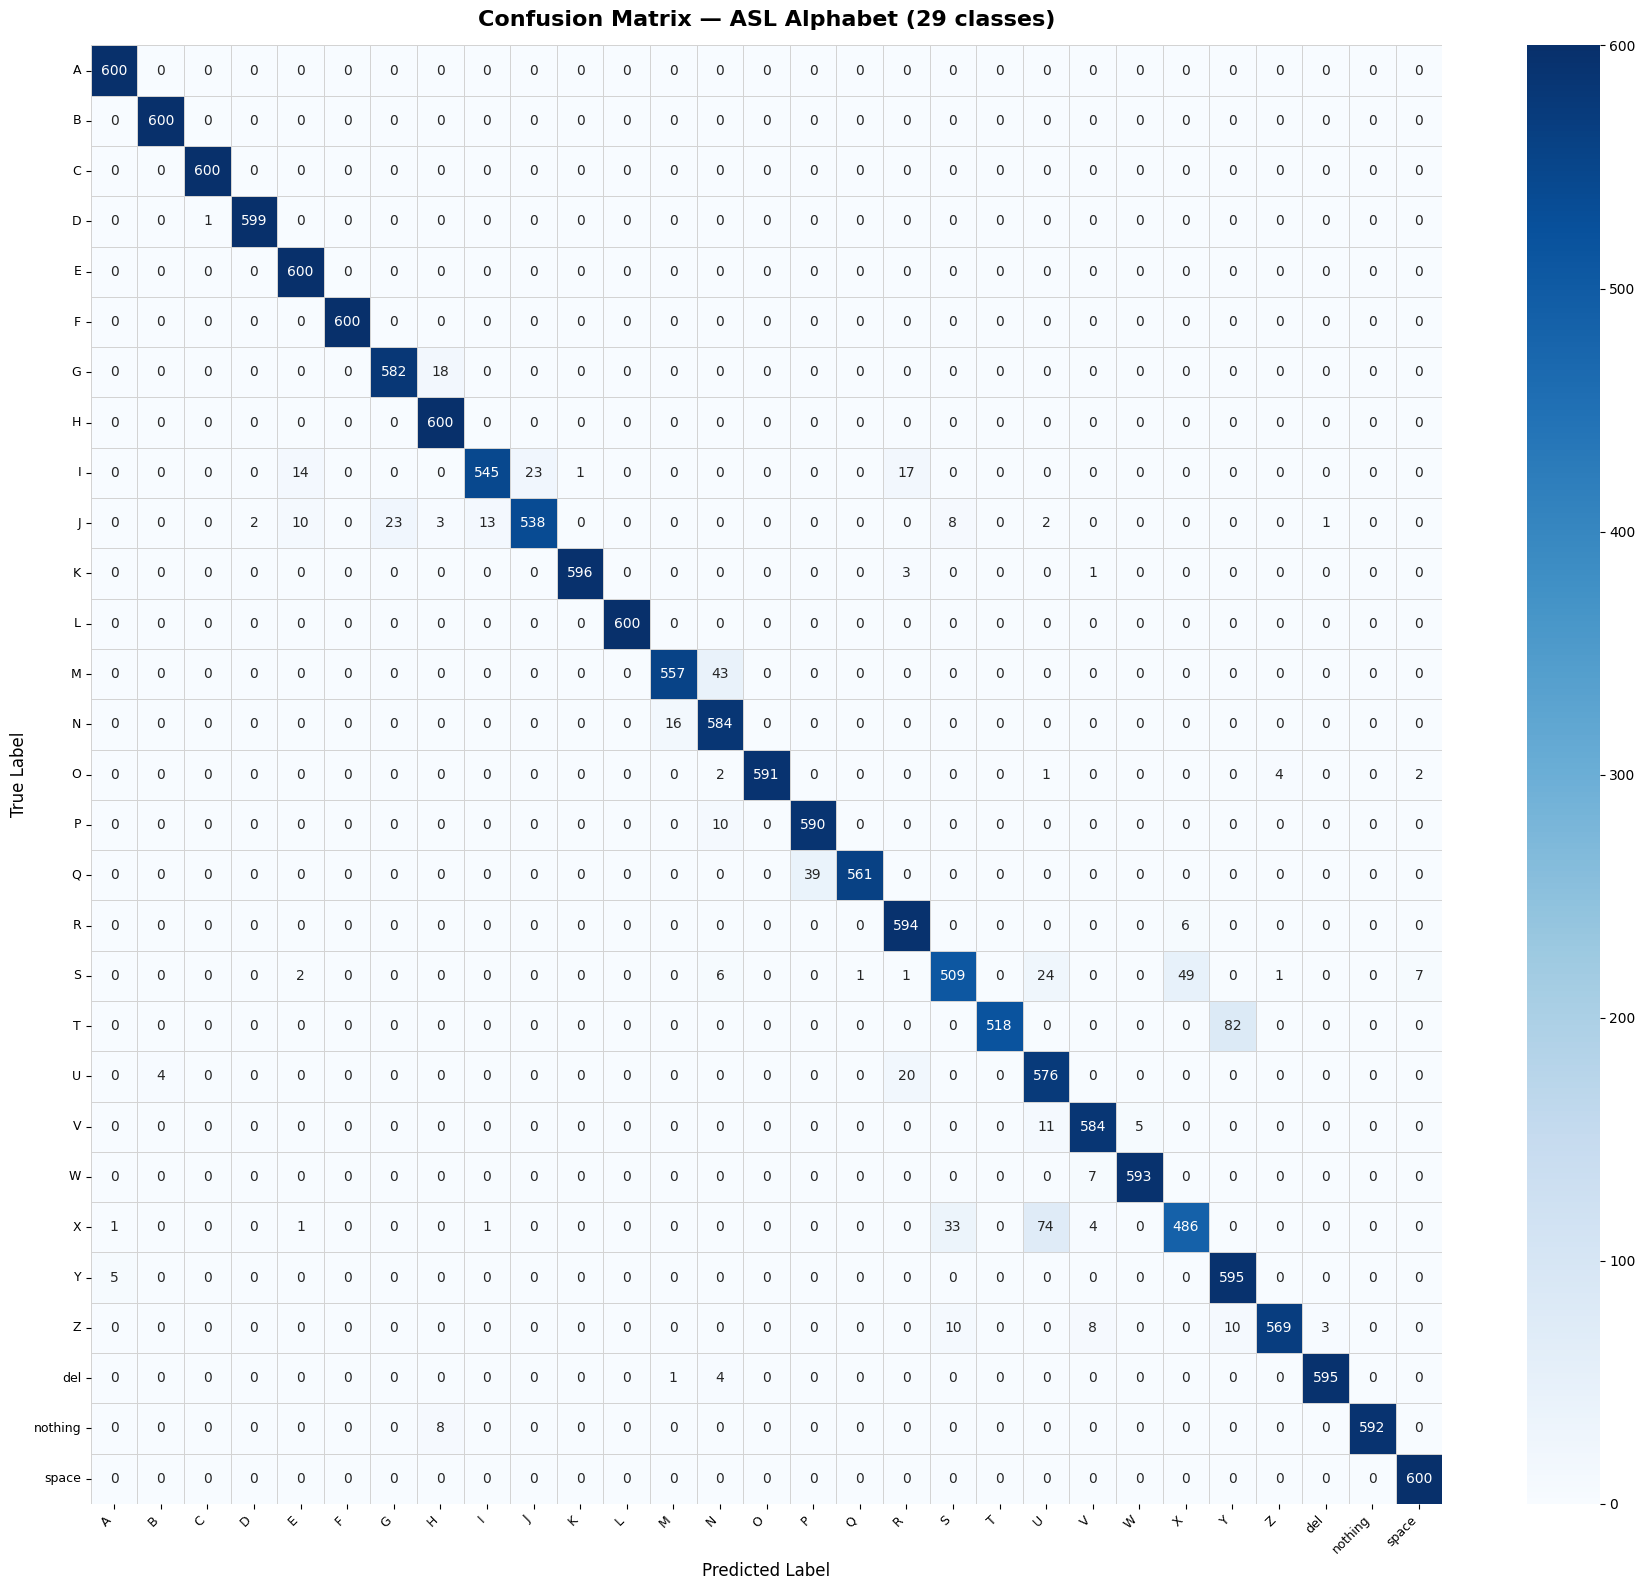


Per-class accuracy (top-5 lowest):
Class  Accuracy
    X  0.810000
    S  0.848333
    T  0.863333
    J  0.896667
    I  0.908333


In [15]:
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(18, 16))
sns.heatmap(
    cm,
    annot        = True,
    fmt          = 'd',
    cmap         = 'Blues',
    xticklabels  = CLASS_NAMES,
    yticklabels  = CLASS_NAMES,
    linewidths   = 0.4,
    linecolor    = 'lightgrey',
    ax           = ax,
)
ax.set_title('Confusion Matrix — ASL Alphabet (29 classes)',
             fontsize=16, fontweight='bold', pad=14)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0,  fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'confusion_matrix.png'), dpi=150)
plt.show()

# per-class accuracy from the diagonal
per_class_acc = cm.diagonal() / cm.sum(axis=1)
df_acc = pd.DataFrame({'Class': CLASS_NAMES, 'Accuracy': per_class_acc})
print('\nPer-class accuracy (top-5 lowest):')
print(df_acc.sort_values('Accuracy').head(5).to_string(index=False))

### 12.3 ROC-AUC Score
We compute the **macro-average One-vs-Rest AUC** across all 29 classes and plot individual ROC curves.

ROC-AUC (macro)    : 0.9997
ROC-AUC (weighted) : 0.9997


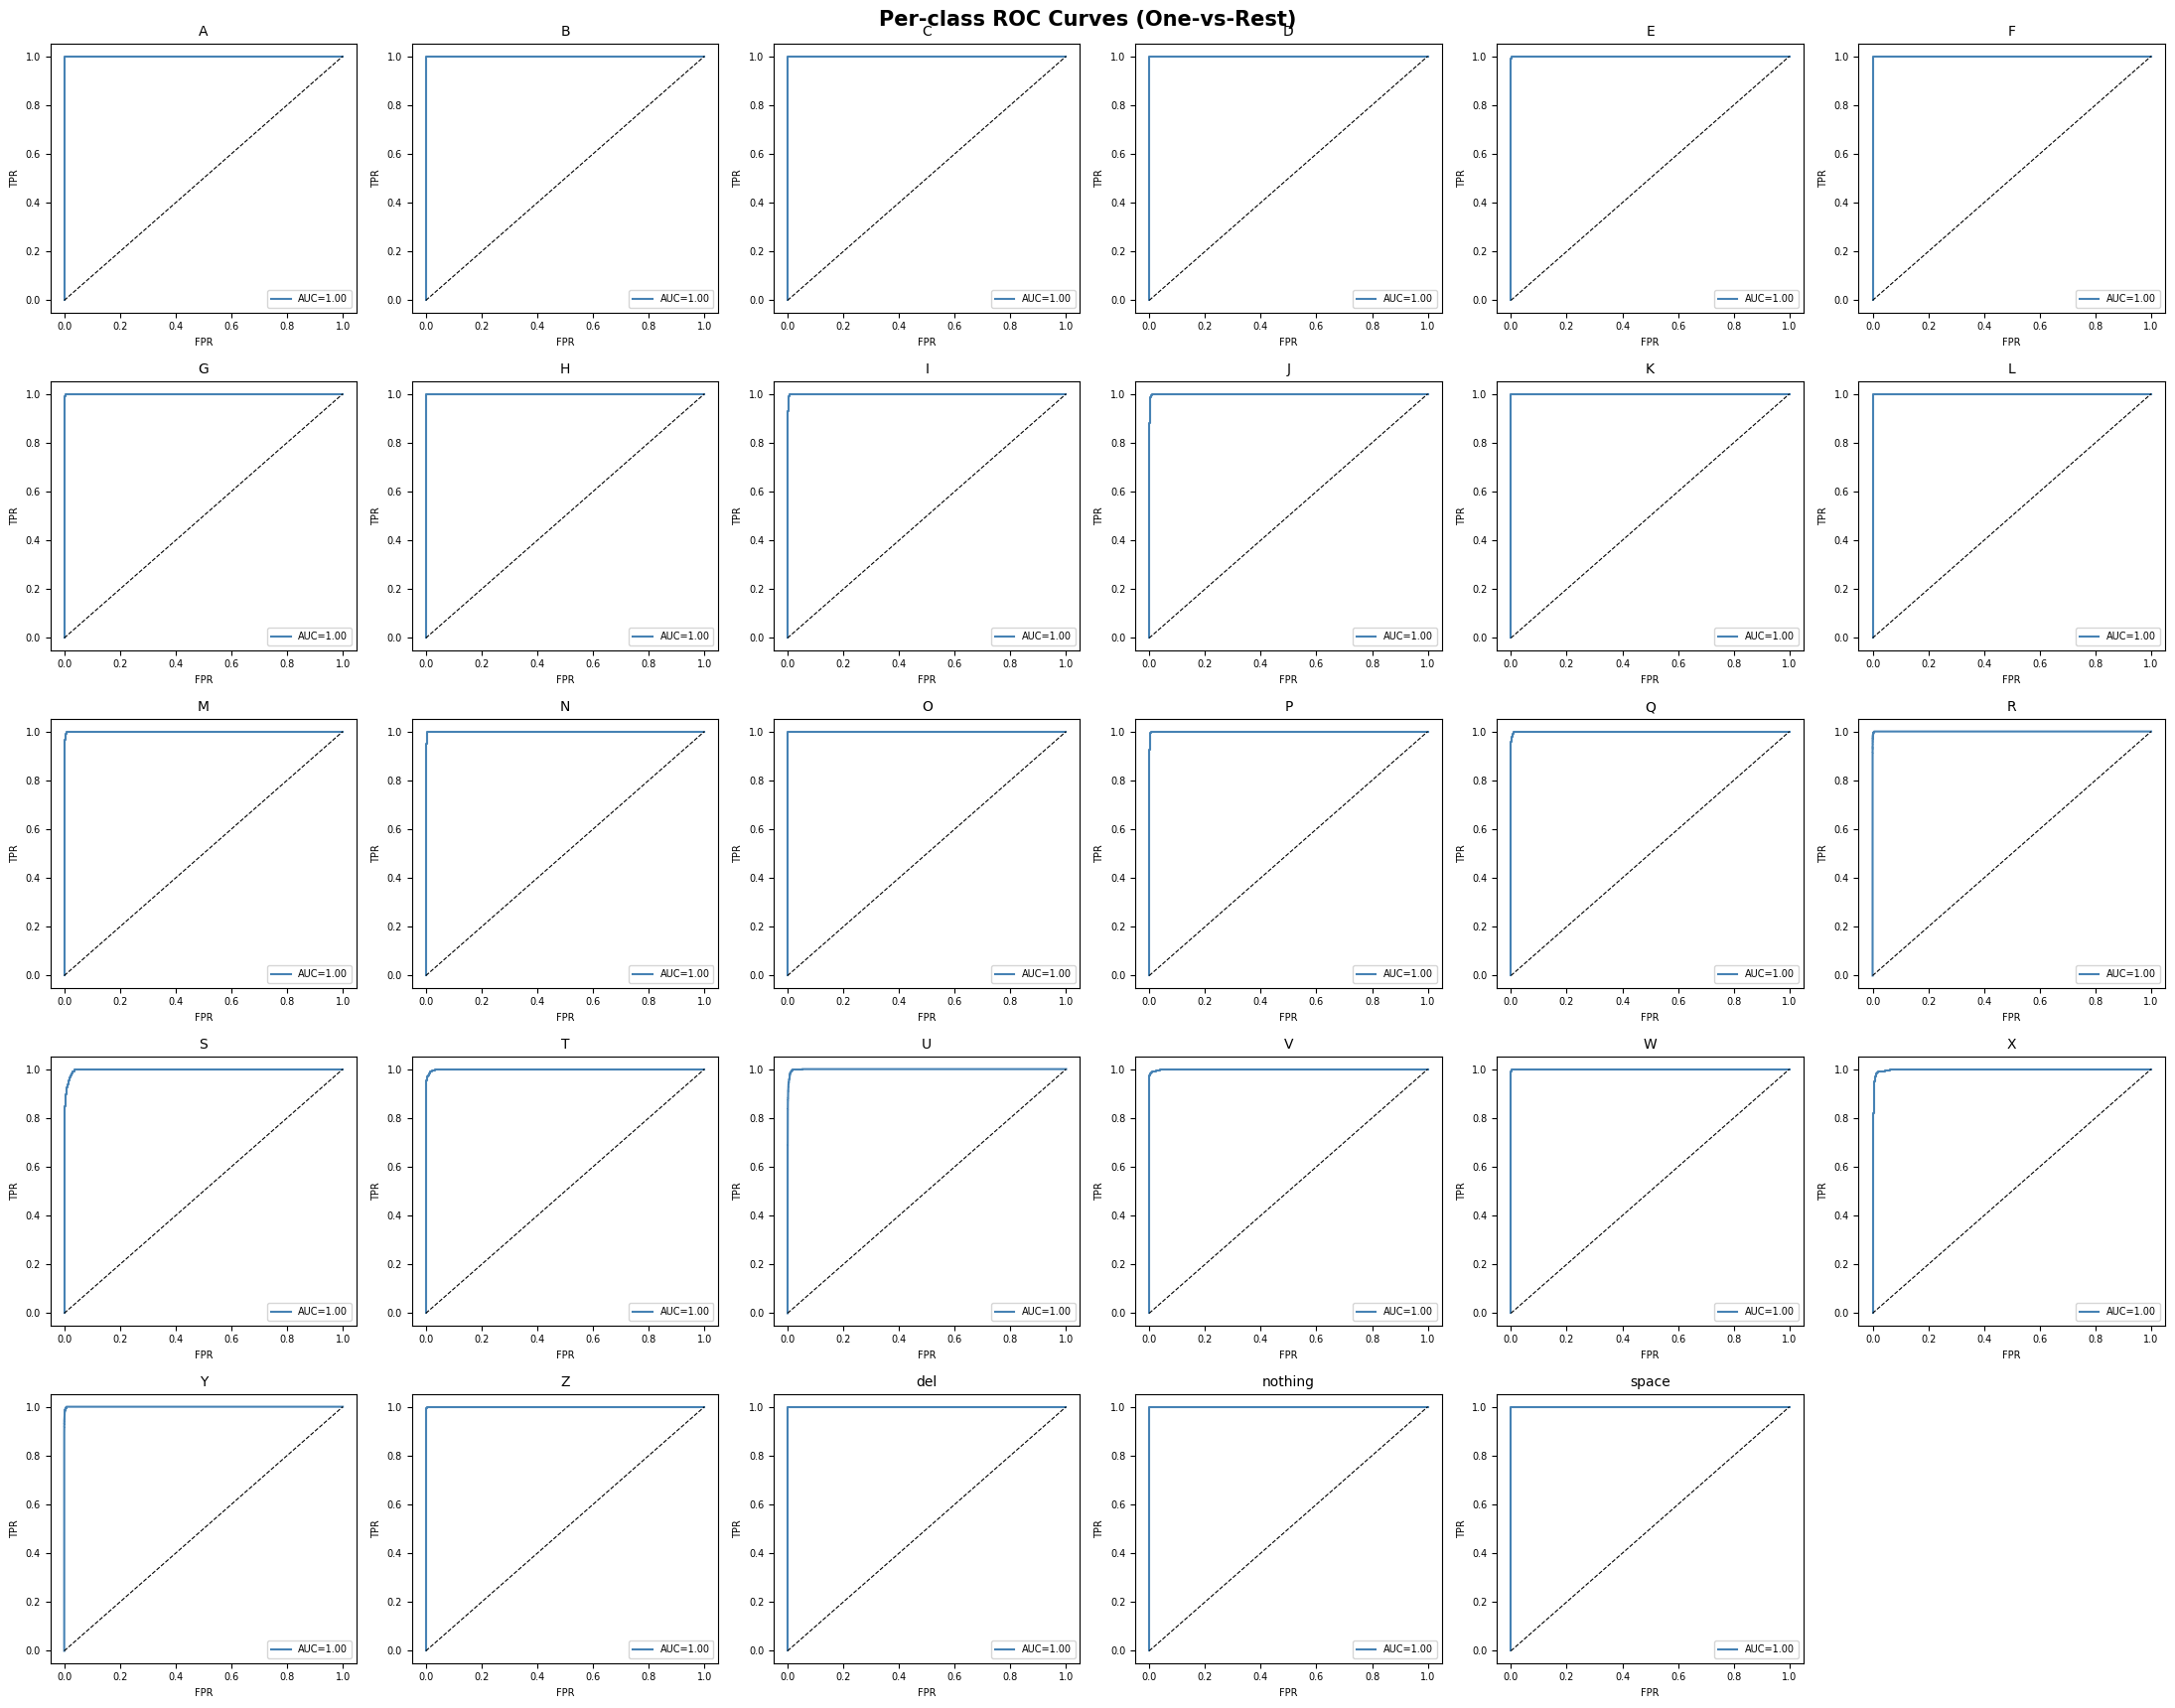

In [16]:
# binarise true labels for OvR AUC
y_true_bin = label_binarize(y_true, classes=list(range(NUM_CLASSES)))

# macro-average AUC
roc_auc_macro = roc_auc_score(
    y_true_bin, y_pred_proba,
    multi_class = 'ovr',
    average     = 'macro',
)
roc_auc_weighted = roc_auc_score(
    y_true_bin, y_pred_proba,
    multi_class = 'ovr',
    average     = 'weighted',
)

print(f'ROC-AUC (macro)    : {roc_auc_macro:.4f}')
print(f'ROC-AUC (weighted) : {roc_auc_weighted:.4f}')

# ── per-class ROC curves (subplot grid) ──────────────────────────────────────
n_cols = 6
n_rows = (NUM_CLASSES + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(22, 3.5 * n_rows))
fig.suptitle('Per-class ROC Curves (One-vs-Rest)', fontsize=15, fontweight='bold')

for i, (ax, cls) in enumerate(zip(axes.flat, CLASS_NAMES)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc_i   = auc(fpr, tpr)
    ax.plot(fpr, tpr, color='steelblue', lw=1.5,
            label=f'AUC={roc_auc_i:.2f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8)
    ax.set_title(cls, fontsize=10)
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlabel('FPR', fontsize=7)
    ax.set_ylabel('TPR', fontsize=7)
    ax.tick_params(labelsize=7)

# hide unused subplots
for ax in axes.flat[NUM_CLASSES:]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'roc_curves.png'), dpi=120)
plt.show()

### 12.4 Per-class Accuracy Bar Chart

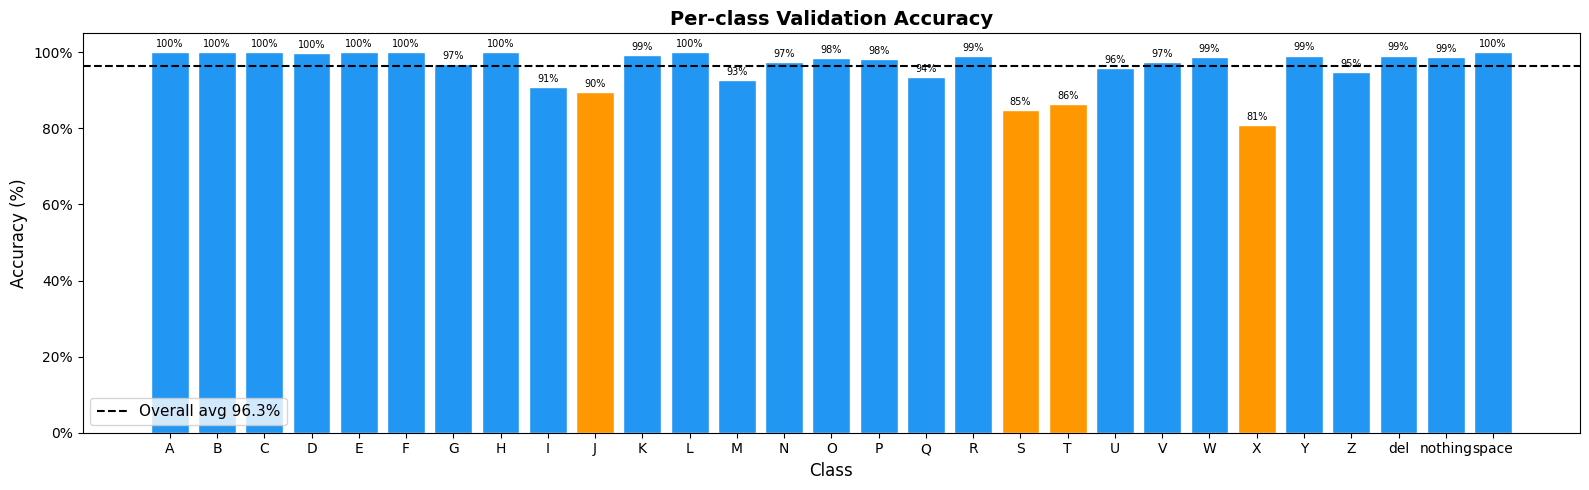

In [17]:
fig, ax = plt.subplots(figsize=(16, 5))
colors = ['#2196F3' if v >= 0.90 else ('#FF9800' if v >= 0.75 else '#F44336')
          for v in per_class_acc]

ax.bar(CLASS_NAMES, per_class_acc * 100, color=colors, edgecolor='white')
ax.axhline(accuracy * 100, color='black', linestyle='--', linewidth=1.5,
           label=f'Overall avg {accuracy*100:.1f}%')
ax.set_ylim(0, 105)
ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Accuracy (%)', fontsize=12)
ax.set_title('Per-class Validation Accuracy', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
for bar, val in zip(ax.patches, per_class_acc):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.8,
            f'{val*100:.0f}%',
            ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig(os.path.join(WORK_DIR, 'per_class_accuracy.png'), dpi=150)
plt.show()

## 13. Save Model
Save the final best model both locally and to Google Drive.

In [1]:
best_model.save(FINAL_PATH)
size_mb = os.path.getsize(FINAL_PATH) / 1e6
print(f'Model saved: {FINAL_PATH}  ({size_mb:.1f} MB)')


NameError: name 'best_model' is not defined

## 14. Quick Inference Demo
Load the saved model from disk and run predictions on a handful of validation images to confirm end-to-end inference works.

In [ ]:
from tensorflow.keras.preprocessing import image as kimage

# reload model from the .h5 file saved to Drive
loaded_model = keras.models.load_model(FINAL_PATH)
print('Model reloaded from Drive ✓')

# pick 8 random validation images
val_paths, val_lbls = [], []
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    cls_dir = os.path.join(TRAIN_DIR, cls_name)
    imgs    = os.listdir(cls_dir)
    # take last ~20% (approximates the validation split)
    split_start = int(len(imgs) * 0.80)
    for img_name in random.sample(imgs[split_start:], 1):
        val_paths.append(os.path.join(cls_dir, img_name))
        val_lbls.append(cls_name)

sample_paths = random.sample(list(zip(val_paths, val_lbls)), 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Inference Demo — Predicted vs True', fontsize=14, fontweight='bold')

for ax, (path, true_cls) in zip(axes.flat, sample_paths):
    img   = kimage.load_img(path, target_size=(IMG_SIZE, IMG_SIZE))
    arr   = kimage.img_to_array(img) / 255.0
    prob  = loaded_model.predict(arr[np.newaxis, ...], verbose=0)[0]
    pred  = CLASS_NAMES[np.argmax(prob)]
    conf  = np.max(prob) * 100
    color = 'green' if pred == true_cls else 'red'
    ax.imshow(img)
    ax.set_title(f'True: {true_cls}\nPred: {pred} ({conf:.1f}%)',
                 fontsize=9, color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(DRIVE_DIR, 'inference_demo.png'), dpi=120)
plt.show()

## 15. Final Summary
Print a clean summary of all key metrics.

In [ ]:
# ── compile metrics ──────────────────────────────────────────────────────────
p1_best_val = max(history1.history['val_accuracy'])
p2_best_val = max(history2.history['val_accuracy'])
p1_epochs   = len(history1.history['loss'])
p2_epochs   = len(history2.history['loss'])

report_dict = classification_report(
    y_true, y_pred,
    target_names = CLASS_NAMES,
    output_dict  = True,
)
macro_f1    = report_dict['macro avg']['f1-score']
weighted_f1 = report_dict['weighted avg']['f1-score']

# ── print banner ─────────────────────────────────────────────────────────────
print('\n' + '=' * 62)
print('   ASL RECOGNITION — EFFICIENTNETB0   FINAL RESULTS')
print('=' * 62)
print(f'  Dataset             : ASL Alphabet (29 classes)')
print(f'  Image size          : {IMG_SIZE} x {IMG_SIZE}')
print(f'  Batch size          : {BATCH_SIZE}')
print(f'  Validation split    : {int(VAL_SPLIT*100)} %')
print(f'  Validation samples  : {eval_gen.samples:,}')
print('-' * 62)
print(f'  Phase 1 epochs ran  : {p1_epochs} / {EPOCHS_PHASE1}')
print(f'  Phase 1 best val acc: {p1_best_val * 100:.2f} %')
print(f'  Phase 2 epochs ran  : {p2_epochs} / {EPOCHS_PHASE2}')
print(f'  Phase 2 best val acc: {p2_best_val * 100:.2f} %')
print('-' * 62)
print(f'  Final Val Accuracy  : {accuracy * 100:.2f} %')
print(f'  Final Val Loss      : {loss:.4f}')
print(f'  Macro  F1-Score     : {macro_f1:.4f}')
print(f'  Weighted F1-Score   : {weighted_f1:.4f}')
print(f'  ROC-AUC (macro OvR) : {roc_auc_macro:.4f}')
print(f'  ROC-AUC (wtd OvR)   : {roc_auc_weighted:.4f}')
print('=' * 62)
print(f'  Model saved to      : {DRIVE_FINAL}')
print(f'  Best ckpt saved to  : {DRIVE_CKPT}')
print('=' * 62)